In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [4]:
jigsaw_train = pd.read_csv("../data/jigsaw_train_refined.csv")
jigsaw_test = pd.read_csv("../data/jigsaw_test_labels_refined.csv")
davidson = pd.read_csv("../data/davidson_test_refined.csv")

In [5]:
print(jigsaw_train.columns)
print(jigsaw_test.columns)
print(davidson.columns)

Index(['text', 'is_toxic'], dtype='str')
Index(['id', 'is_toxic'], dtype='str')
Index(['text', 'is_toxic'], dtype='str')


In [7]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

# Clean Jigsaw train data
jigsaw_train['clean_text'] = (
    jigsaw_train['text'].apply(clean_text)
)

# Clean Davidson data
davidson['clean_text'] = (
    davidson['text'].apply(clean_text)
) 

In [8]:
from sklearn.model_selection import train_test_split

X = jigsaw_train['clean_text']
y = jigsaw_train['is_toxic']

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train = vectorizer.fit_transform(
    X_train_text
)

X_test = vectorizer.transform(
    X_test_text
)

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [12]:
predictions = model.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.98      0.94      0.96     28671
           1       0.62      0.85      0.72      3244

    accuracy                           0.93     31915
   macro avg       0.80      0.90      0.84     31915
weighted avg       0.95      0.93      0.94     31915



In [14]:
import os

os.makedirs("../results", exist_ok=True)

In [15]:
report = classification_report(
    y_test,
    predictions
)

with open(
    "../results/baseline_metrics.txt",
    "w"
) as f:
    f.write(report)

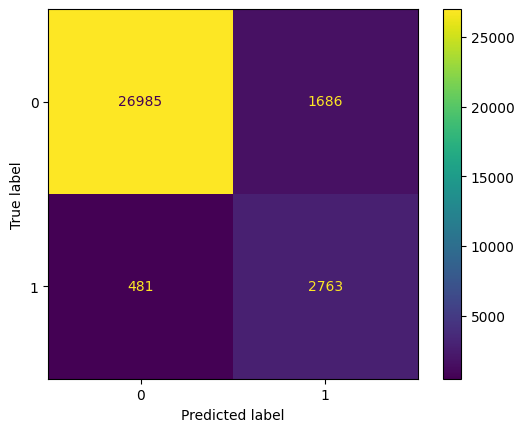

In [16]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig(
    "../results/confusion_matrix_jigsaw.png"
)

plt.show()

In [17]:
X_davidson = vectorizer.transform(
    davidson['clean_text']
)

y_davidson = davidson['is_toxic']

davidson_predictions = model.predict(
    X_davidson
)

print(
    classification_report(
        y_davidson,
        davidson_predictions
    )
)

              precision    recall  f1-score   support

           0       0.47      0.66      0.55      4163
           1       0.93      0.85      0.89     20620

    accuracy                           0.82     24783
   macro avg       0.70      0.76      0.72     24783
weighted avg       0.85      0.82      0.83     24783



In [18]:
report = classification_report(
    y_davidson,
    davidson_predictions
)

with open(
    "../results/cross_platform_metrics.txt",
    "w"
) as f:
    f.write(report)

In [19]:
davidson['prediction'] = davidson_predictions

davidson.to_csv(
    "../results/davidson_predictions.csv",
    index=False
)

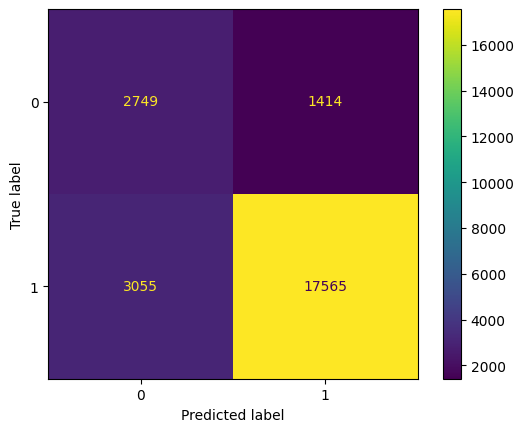

In [20]:
cm = confusion_matrix(
    y_davidson,
    davidson_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.savefig(
    "../results/confusion_matrix_davidson.png"
)

plt.show()